In [14]:
import numpy as np
import cv2
import json
import os
import random
from scipy.interpolate import splprep, splev

IMG_SIZE            = (512, 512)
NUM_IMAGES_PER_TIER = 10
NUM_CALIBRATION     = 20
OUTPUT_DIR          = "synthetic_fault_lines_realistic"

TIERS = {
    "group1_straight":      dict(curvature=False, gaps=False, thick=(1,2),  n_lines=(2,6),   width_range=(2,4),  bright=False),
    "group2_gaps":          dict(curvature=False, gaps=True,  thick=(3,6),  n_lines=(2,6),   width_range=(2,4),  bright=False),
    "group3_curved":        dict(curvature=True,  gaps=False, thick=(3,6),  n_lines=(4,10),  width_range=(2,4),  bright=False),
    "group4_dense_overlap": dict(curvature=True,  gaps=True,  thick=(2,8),  n_lines=(10,20), width_range=(2,6),  bright=False),
    "group5_mixed_widths":  dict(curvature=False, gaps=False, thick=(1,16), n_lines=(2,6),   width_range=(1,16), bright=False),
    "group6_mixed_type":    dict(curvature=False, gaps=False, thick=(2,6),  n_lines=(4,10),  width_range=(2,6),  bright=None),
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "calibration"), exist_ok=True)
for tier in TIERS:
    os.makedirs(os.path.join(OUTPUT_DIR, tier), exist_ok=True)


# ── Geometry ──────────────────────────────────────────────────────────────────

def random_spline_points(n_points=8, curvature=0.2):
    x   = np.linspace(40, IMG_SIZE[1]-40, n_points) + np.random.uniform(-10, 10, n_points)
    y   = np.linspace(80, IMG_SIZE[0]-80, n_points) + np.random.normal(0, 1 + 4*curvature, n_points)
    pts = np.column_stack((x, y))
    angle = np.random.uniform(-np.pi/6, np.pi/6)
    rot   = np.array([[np.cos(angle), -np.sin(angle)],
                      [np.sin(angle),  np.cos(angle)]])
    pts   = pts @ rot.T
    pts   = np.clip(pts, [0, 0], [IMG_SIZE[1]-1, IMG_SIZE[0]-1])
    pts   = pts[np.argsort(pts[:, 0])]
    if len(pts) < 6:
        return pts.astype(np.int32)
    try:
        tck, _ = splprep([pts[:, 0], pts[:, 1]], s=curvature*10, k=1)
        x_new, y_new = splev(np.linspace(0, 1, 120), tck)
        return np.column_stack((x_new, y_new)).astype(np.int32)
    except Exception:
        return pts.astype(np.int32)


def generate_piecewise_linear(n_segments=2):
    all_pts   = []
    x         = random.uniform(80, IMG_SIZE[1]-80)
    y         = random.uniform(80, IMG_SIZE[0]-80)
    direction = random.uniform(-np.pi, np.pi)
    for _ in range(n_segments):
        length     = random.uniform(150, 420)
        direction += np.random.normal(0, 0.03)
        x_end = np.clip(x + length*np.cos(direction), 30, IMG_SIZE[1]-30)
        y_end = np.clip(y + length*np.sin(direction), 30, IMG_SIZE[0]-30)
        actual_len = np.hypot(x_end - x, y_end - y)
        if actual_len < 30:
            x_end = np.clip(x + 150*np.cos(direction), 30, IMG_SIZE[1]-30)
            y_end = np.clip(y + 150*np.sin(direction), 30, IMG_SIZE[0]-30)
            actual_len = np.hypot(x_end - x, y_end - y)
        n_pts = max(40, int(actual_len / 2))
        xs    = np.linspace(x, x_end, n_pts)
        ys    = np.linspace(y, y_end, n_pts)
        all_pts.append(np.column_stack((xs, ys)))
        x, y  = x_end, y_end
    if not all_pts:
        xs = np.linspace(80, IMG_SIZE[1]-80, 60)
        ys = np.linspace(80, IMG_SIZE[0]-80, 60)
        all_pts.append(np.column_stack((xs, ys)))
    return np.vstack(all_pts).astype(np.int32)


def generate_fault_network(n_lines_range, high_curvature):
    lines = []
    for _ in range(random.randint(*n_lines_range)):
        if random.random() < (0.6 if high_curvature else 1.0):
            pts = generate_piecewise_linear(n_segments=random.randint(1, 3))
        else:
            pts = random_spline_points(curvature=random.uniform(0.15, 0.40))
        if len(pts) >= 40:
            lines.append(pts)
    return lines


def add_gaps(lines, gap_prob=0.3):
    gapped = []
    for pts in lines:
        if random.random() > gap_prob or len(pts) < 30:
            gapped.append(pts)
            continue
        mask    = np.ones(len(pts), dtype=bool)
        max_gap = max(4, len(pts) // 6)
        start   = random.randint(len(pts)//4, 3*len(pts)//4)
        gap_len = random.randint(3, max_gap)
        mask[start:start+gap_len] = False
        segments, seg = [], []
        for k, keep in enumerate(mask):
            if keep:
                seg.append(pts[k])
            elif seg:
                if len(seg) >= 15:
                    segments.append(np.array(seg, dtype=np.int32))
                seg = []
        if len(seg) >= 15:
            segments.append(np.array(seg, dtype=np.int32))
        gapped.extend(segments if segments else [pts])
    return gapped


# ── Background ────────────────────────────────────────────────────────────────

def make_background(real_spectrum=None):
    H, W = IMG_SIZE
    if real_spectrum is not None:
        power = real_spectrum
    else:
        fy = np.fft.fftfreq(H)[:, None]
        fx = np.fft.fftfreq(W)[None, :]
        f  = np.sqrt(fx**2 + fy**2)
        f[0, 0]     = 1.0
        power       = 1.0 / (f ** 2)
        power[0, 0] = 0.0
    phase = np.random.uniform(0, 2*np.pi, (H, W))
    field = np.real(np.fft.ifft2(np.sqrt(power) * np.exp(1j * phase)))
    field = 128.0 + 25.0 * field / (field.std() + 1e-8)
    return np.clip(field, 0, 255).astype(np.uint8)


def measure_power_spectrum(image_patches):
    spectra = []
    for patch in image_patches:
        f = np.fft.fft2(patch.astype(np.float32))
        spectra.append(np.abs(f) ** 2)
    return np.mean(spectra, axis=0)


# ── Rasterise — explicit Python int tuples for cv2 compatibility ──────────────

def draw_line(canvas, p1, p2, colour, thick):
    cv2.line(canvas,
             (int(p1[0]), int(p1[1])),
             (int(p2[0]), int(p2[1])),
             colour, thick, lineType=cv2.LINE_8)


def rasterize_lines(canvas, lines, thickness_range):
    """Always draws 255 — composite() applies dark/bright effect."""
    for pts in lines:
        thick = random.randint(*thickness_range)
        for i in range(len(pts)-1):
            draw_line(canvas, pts[i], pts[i+1], 255, thick)


# ── Composite ─────────────────────────────────────────────────────────────────

def composite(bg, fault_canvas, bright=False):
    alpha = fault_canvas.astype(np.float32) / 255.0
    bg_f  = bg.astype(np.float32)
    if bright:
        final = np.clip(bg_f + 80.0 * alpha, 0, 255)
    else:
        final = np.clip(bg_f * (1 - 0.6 * alpha), 0, 255)
    return final.astype(np.uint8)


# ── Main ──────────────────────────────────────────────────────────────────────

def main(real_spectrum=None):
    print(f"Generating {NUM_CALIBRATION} calibration images (background only)...")
    cal_dir = os.path.join(OUTPUT_DIR, "calibration")
    for i in range(NUM_CALIBRATION):
        bg = make_background(real_spectrum=real_spectrum)
        cv2.imwrite(os.path.join(cal_dir, f"cal_{i:04d}.png"), bg)
    print(f"  Done.\n")

    for tier, cfg in TIERS.items():
        print(f"Generating {NUM_IMAGES_PER_TIER} images for {tier} ...")
        tier_dir = os.path.join(OUTPUT_DIR, tier)

        for i in range(NUM_IMAGES_PER_TIER):

            for attempt in range(20):
                lines = generate_fault_network(
                    n_lines_range=cfg["n_lines"],
                    high_curvature=cfg["curvature"],
                )
                if cfg["gaps"]:
                    lines = add_gaps(lines)

                fault_canvas = np.zeros(IMG_SIZE, dtype=np.uint8)

                if cfg["bright"] is None:
                    # mixed type — rasterise each line separately
                    for pts in lines:
                        tmp   = np.zeros(IMG_SIZE, dtype=np.uint8)
                        thick = random.randint(*cfg["thick"])
                        for j in range(len(pts)-1):
                            draw_line(tmp, pts[j], pts[j+1], 255, thick)
                        fault_canvas = np.maximum(fault_canvas, tmp)
                else:
                    rasterize_lines(fault_canvas, lines, cfg["thick"])

                if fault_canvas.max() > 0:
                    break
            else:
                print(f"  WARNING: skipping {tier} img {i} — empty after 20 attempts")
                continue

            bg = make_background(real_spectrum=real_spectrum)

            if cfg["bright"] is None:
                final = bg.astype(np.float32)
                for pts in lines:
                    is_bright = random.random() < 0.5
                    tmp       = np.zeros(IMG_SIZE, dtype=np.uint8)
                    thick     = random.randint(*cfg["thick"])
                    for j in range(len(pts)-1):
                        draw_line(tmp, pts[j], pts[j+1], 255, thick)
                    alpha = tmp.astype(np.float32) / 255.0
                    if is_bright:
                        final = np.clip(final + 80.0 * alpha, 0, 255)
                    else:
                        final = np.clip(final * (1 - 0.6 * alpha), 0, 255)
                final = final.astype(np.uint8)
            else:
                final = composite(bg, fault_canvas, bright=cfg["bright"])

            img_path = os.path.join(tier_dir, f"img_{i:04d}.png")
            gt_path  = os.path.join(tier_dir, f"img_{i:04d}_gt.json")

            cv2.imwrite(img_path, final)

            gt = [{"points": pts.tolist()} for pts in lines]
            with open(gt_path, "w") as f:
                json.dump({
                    "lines":      gt,
                    "image_size": list(IMG_SIZE),
                    "bright":     cfg["bright"],
                }, f, indent=2)

            if (i+1) % 10 == 0:
                print(f"  {i+1}/{NUM_IMAGES_PER_TIER}")

    print(f"\nDone. Saved to {OUTPUT_DIR}/")


if __name__ == "__main__":
    random.seed(42)
    np.random.seed(42)
    main()



Generating 20 calibration images (background only)...
  Done.

Generating 10 images for group1_straight ...
  10/10
Generating 10 images for group2_gaps ...
  10/10
Generating 10 images for group3_curved ...
  10/10
Generating 10 images for group4_dense_overlap ...
  10/10
Generating 10 images for group5_mixed_widths ...
  10/10
Generating 10 images for group6_mixed_type ...
  10/10

Done. Saved to synthetic_fault_lines_realistic/


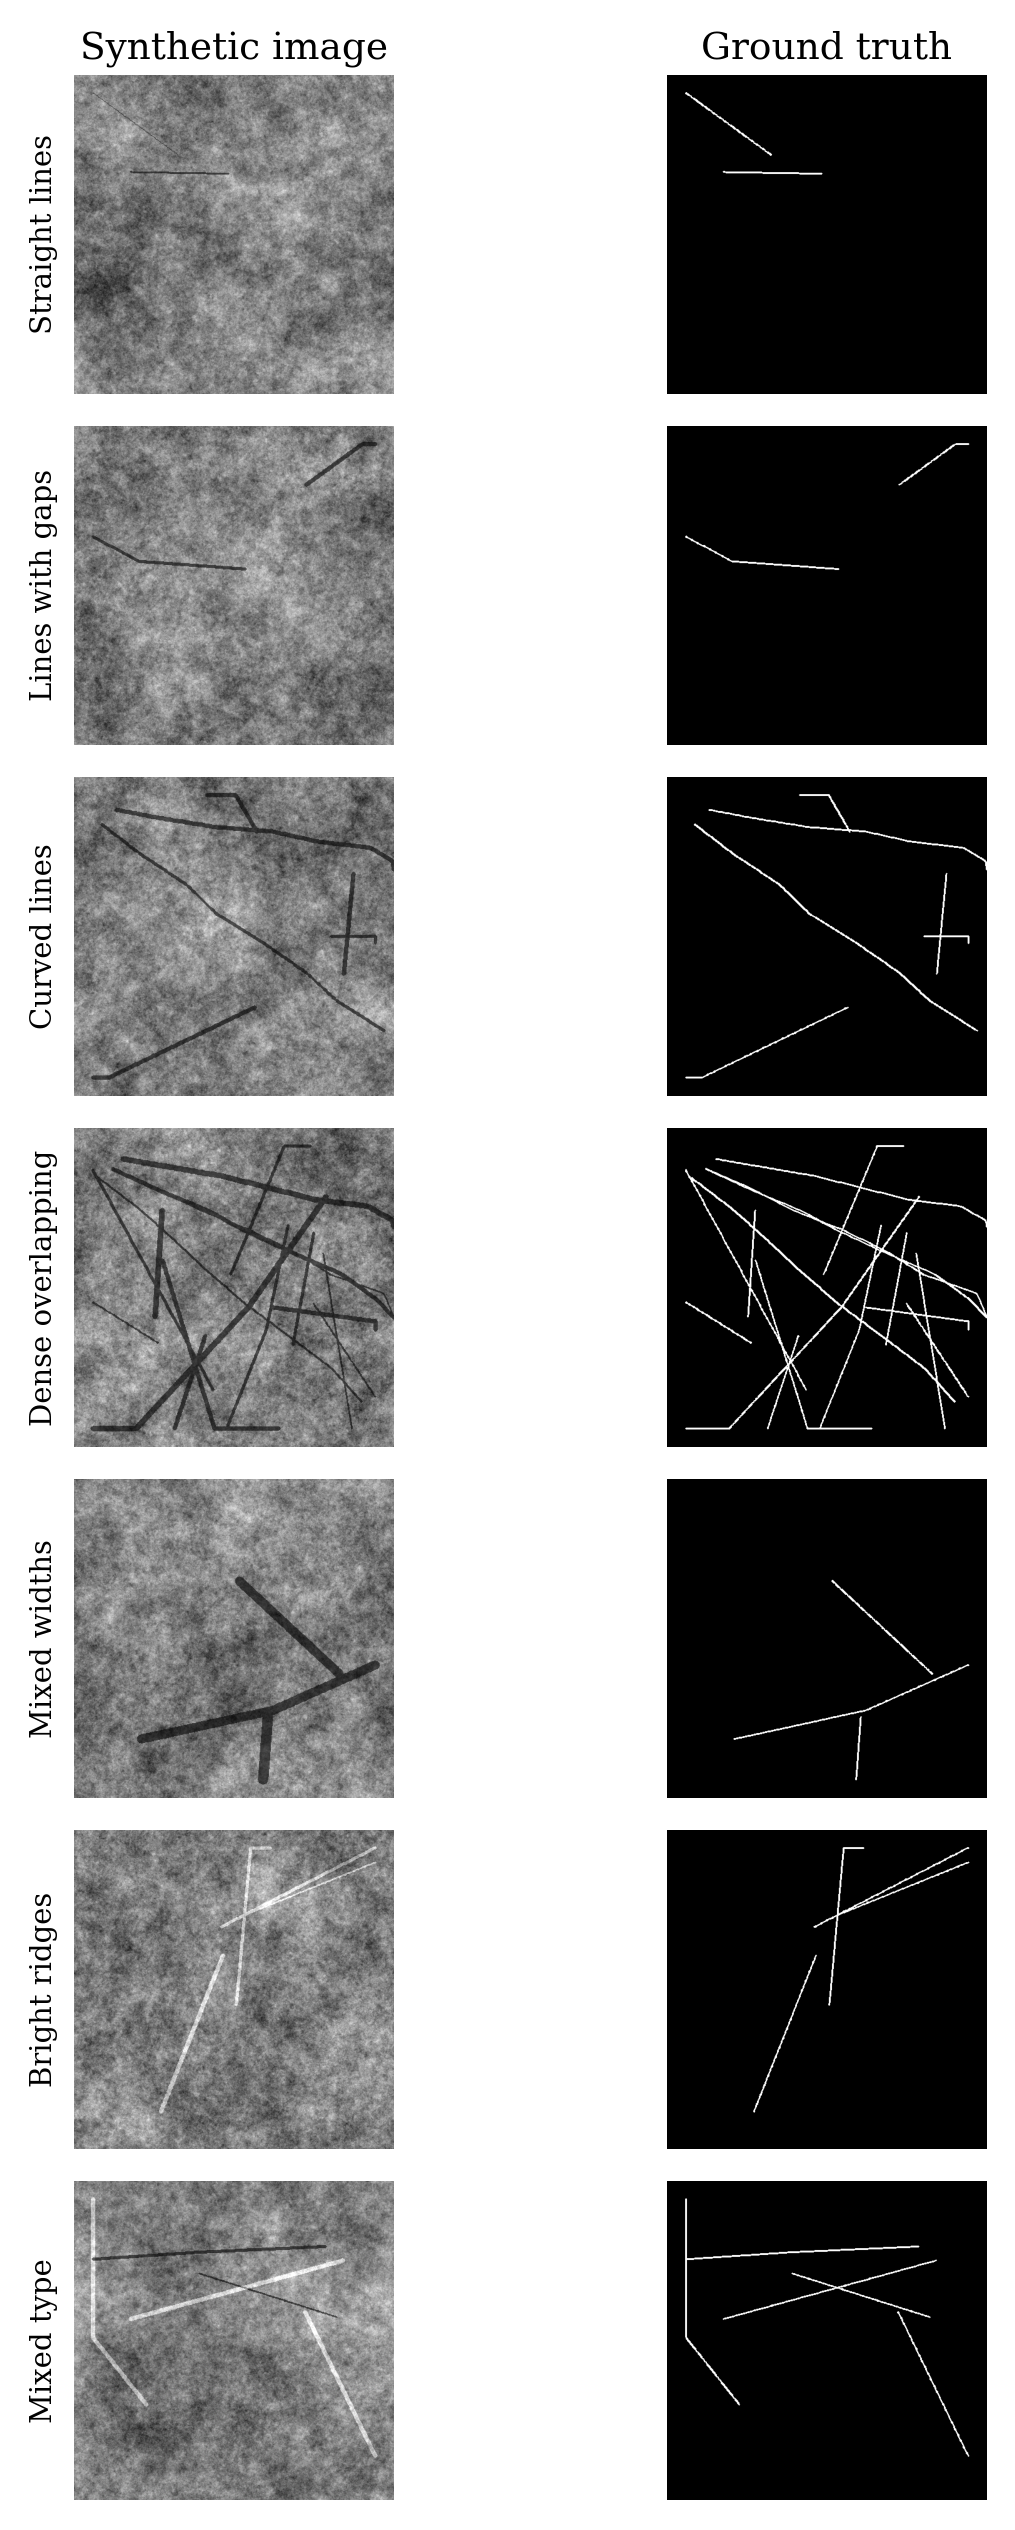

Saved fig1_benchmark_overview.pdf + .png


In [ ]:
"""
Figure 1 — Synthetic Benchmark Overview
One row per tier, 2 columns: synthetic image | ground truth
"""
from pathlib import Path
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family":    "serif",
    "font.size":      9,
    "axes.titlesize": 9,
    "figure.dpi":     300,
    "savefig.dpi":    300,
    "savefig.bbox":   "tight",
})

BASE = Path("/Users/viktoriadergunov/fault_structure_toolbox/synthetic_fault_lines_realistic")

TIERS = {
    "group1_straight":      "Straight lines",
    "group2_gaps":          "Lines with gaps",
    "group3_curved":        "Curved lines",
    "group4_dense_overlap": "Dense overlapping",
    "group5_mixed_widths":  "Mixed widths",
    "group6_mixed_type":    "Mixed type",
}


def load_pair(tier_dir):
    """Load first valid image and GT mask from a tier folder."""
    for img_path in sorted(Path(tier_dir).glob("*.png")):
        if "_gt" in img_path.stem:
            continue
        gt_path = img_path.with_name(img_path.stem + "_gt.json")
        if not gt_path.exists():
            continue

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        with open(gt_path) as f:
            gt_data = json.load(f)
        H, W    = gt_data["image_size"]
        gt_mask = np.zeros((H, W), dtype=np.uint8)
        for line in gt_data["lines"]:
            pts = np.array(line["points"], dtype=np.int32)
            for i in range(len(pts) - 1):
                cv2.line(gt_mask,
                         (int(pts[i][0]),   int(pts[i][1])),
                         (int(pts[i+1][0]), int(pts[i+1][1])),
                         255, 2)

        return img, gt_mask
    return None, None


# ── Build figure ──────────────────────────────────────────────────────────────
n_tiers = len(TIERS)
fig, axes = plt.subplots(n_tiers, 2,
                         figsize=(5, n_tiers * 1.5),
                         gridspec_kw=dict(wspace=0.04, hspace=0.10))

col_titles = ["Synthetic image", "Ground truth"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9, pad=4)

for row, (tier_key, tier_label) in enumerate(TIERS.items()):
    tier_dir = BASE / tier_key
    img, gt  = load_pair(tier_dir)

    if img is None:
        for col in range(2):
            axes[row, col].axis("off")
            axes[row, col].text(0.5, 0.5, "no data",
                                transform=axes[row, col].transAxes,
                                ha="center", va="center", fontsize=7,
                                color="gray")
        continue

    # Column 0 — synthetic image
    axes[row, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].axis("off")
    axes[row, 0].text(-0.05, 0.5, tier_label, fontsize=7,
                      transform=axes[row, 0].transAxes,
                      va="center", ha="right", rotation=90)

    # Column 1 — GT mask
    axes[row, 1].imshow(gt, cmap="gray", vmin=0, vmax=255)
    axes[row, 1].axis("off")

plt.savefig("fig1_benchmark_overview.pdf", bbox_inches="tight")
plt.savefig("fig1_benchmark_overview.png", bbox_inches="tight")
plt.show()
print("Saved fig1_benchmark_overview.pdf + .png")